# 02 — Feature Selection

This notebook ranks all 300 NLP features using three methods:
1. **Permutation Importance with Random Forest**
2. **Permutation Importance with Logistic Regression**  
3. **XGBoost built-in feature importance**

We then take the **union of the top-50 features** from each method to form a robust feature set of ~90 features used for modelling.

## Setup — Load Data & Split

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# load featues
X_train = pd.read_csv("../raw datasets/X_train.csv")
y_train = pd.read_csv("../raw datasets/y_train.csv")

# train features
x_train, x_test, y_train_split, y_test_split = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train, # ensure class distribution is preserved
    random_state=42 #ensures that the train/test split is reproducible every time you run your code.
)
# flattens dataset scikit-learn functions expect a 1D array for classification targets, like (8000,)
y_train_split = y_train_split.values.ravel()
y_test_split = y_test_split.values.ravel()


# Fit scaler on training data
scaler = StandardScaler()
scaler.fit(x_train)

# Transform without overwriting yet
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Convert scaled arrays back into DataFrames
x_train = pd.DataFrame(x_train_scaled, columns=X_train.columns, index=x_train.index)
x_test = pd.DataFrame(x_test_scaled, columns=X_train.columns, index=x_test.index)


## Method 1 — Permutation Importance with Random Forest

We train a Random Forest and measure how much each feature degrades the weighted log loss when shuffled. Features that cause the largest degradation are most important.

In [2]:
# permutation importance + random forest

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(x_train, y_train_split)

# Weighted Log Loss scorer
def weighted_log_loss_scorer(estimator, X, y_true):
    y_pred = estimator.predict_proba(X)
    y_true_ohe = label_binarize(y_true, classes=np.unique(y_train_split))
    class_counts = np.sum(y_true_ohe, axis=0)
    class_weights = 1.0 / class_counts
    class_weights /= np.sum(class_weights)
    sample_weights = np.sum(y_true_ohe * class_weights, axis=1)
    loss = np.mean(-sample_weights * np.sum(y_true_ohe * np.log(y_pred + 1e-15), axis=1))
    return -loss  # negate for scorer convention

# Run permutation importance
print("Running permutation importance with Random Forest...")
perm_result = permutation_importance(
    model,
    x_train,
    y_train_split,
    scoring=weighted_log_loss_scorer,
    n_repeats=5, # shuffle each feature 5 times and average the impact on the score
    random_state=42,
    n_jobs=-1 # how many CPU cores to use (use all available cores for maximum speed)
)

# Rank features
importances = perm_result.importances_mean
perm_rf_ranking = np.argsort(importances)[::-1]

Running permutation importance with Random Forest...


### Tune top-k: find how many RF features to keep

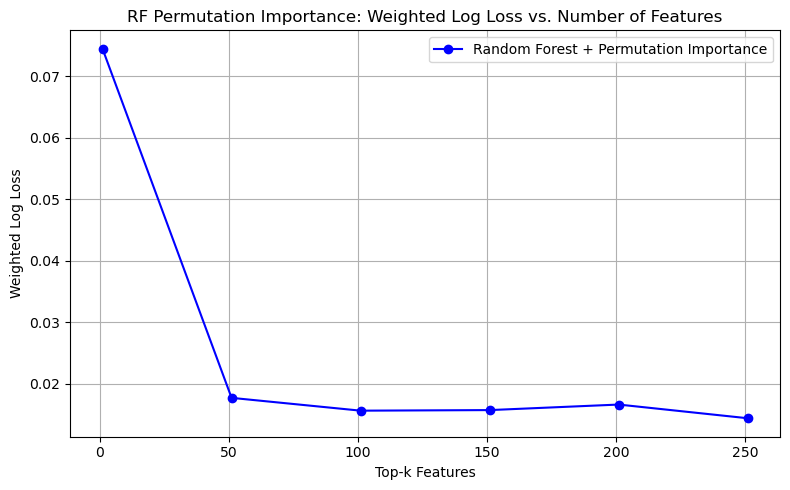

In [3]:
# selecting top-k features for random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Your pre-computed importance-based ranking
perm_rf_ranking = np.argsort(perm_result.importances_mean)[::-1]

# Try using different top-k feature counts
k_values = list(range(1, 300, 50))
wll_scores_rf = []

for k in k_values:
    # Select top-k feature indices
    top_k_features = perm_rf_ranking[:k]
    
    # Filter datasets to use only those features
    x_train_k = x_train.iloc[:, top_k_features]
    x_test_k = x_test.iloc[:, top_k_features]

    # Train model
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=0)
    model.fit(x_train_k, y_train_split)
    
    # Predict probabilities
    y_pred = model.predict_proba(x_test_k)

    # Calculate weighted log loss
    y_true_ohe = label_binarize(y_test_split, classes=np.unique(y_train_split))
    class_counts = np.sum(y_true_ohe, axis=0)
    class_weights = 1.0 / class_counts
    class_weights /= np.sum(class_weights)
    sample_weights = np.sum(y_true_ohe * class_weights, axis=1)
    loss = np.mean(-sample_weights * np.sum(y_true_ohe * np.log(y_pred + 1e-15), axis=1))
    
    wll_scores_rf.append(loss)

# Plot WLL vs Top-k Features
plt.figure(figsize=(8,5))
plt.plot(k_values, wll_scores_rf, marker='o', color='blue', label='Random Forest + Permutation Importance')
plt.xlabel('Top-k Features')
plt.ylabel('Weighted Log Loss')
plt.title('RF Permutation Importance: Weighted Log Loss vs. Number of Features')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Method 2 — Permutation Importance with Logistic Regression

Same approach but using Logistic Regression as the estimator. This captures linear feature importance, complementing the RF non-linear rankings.

In [4]:
# permutation importance + logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize

def weighted_log_loss_scorer(estimator, X, y_true):
    y_pred = estimator.predict_proba(X)
    y_true_ohe = label_binarize(y_true, classes=np.unique(y_true))
    class_counts = np.sum(y_true_ohe, axis=0)
    class_weights = 1.0 / class_counts
    class_weights /= np.sum(class_weights)  # Normalize weights to sum to 1
    sample_weights = np.sum(y_true_ohe * class_weights, axis=1)
    loss = np.mean(-sample_weights * np.sum(y_true_ohe * np.log(y_pred + 1e-15), axis=1))
    return -loss  # negate for sklearn convention (higher is better)

# 1. Train logistic regression model
lr_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(x_train, y_train_split.ravel())

# 2. Run permutation importance with same weighted log loss scorer
print("Running permutation importance (Logistic Regression)...")
perm_result_lr = permutation_importance(
    lr_model,
    x_train,
    y_train_split.ravel(),
    scoring=weighted_log_loss_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# 3. Sort importances
importances = perm_result_lr.importances_mean
perm_lr_ranking = np.argsort(importances)[::-1]

Running permutation importance (Logistic Regression)...


### Tune top-k: find how many LR features to keep

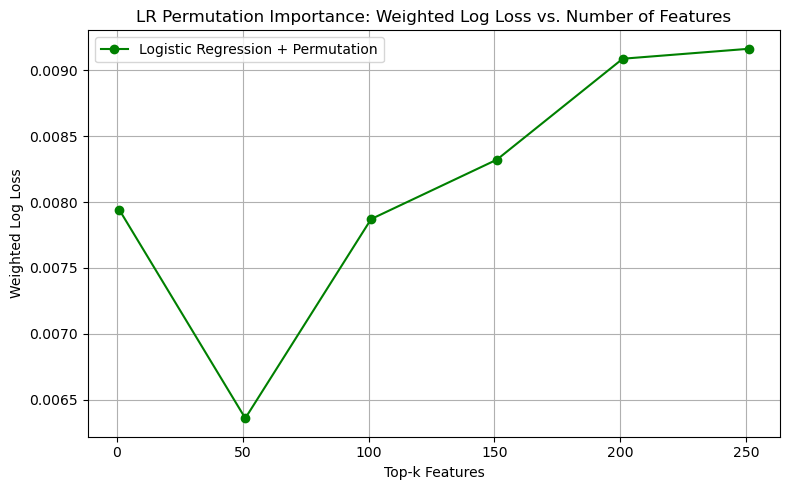

In [5]:
# selecting top-k features for logistic regression
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt


k_values = list(range(1, 300, 50))
wll_scores_lr = []

for k in k_values:
    top_k_features = perm_lr_ranking[:k]
    x_train_k = x_train.iloc[:, top_k_features]
    x_test_k = x_test.iloc[:, top_k_features]
    
    model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced')
    model.fit(x_train_k, y_train_split)
    
    y_pred = model.predict_proba(x_test_k)
    
    # Get weighted log loss on test set
    y_true_ohe = label_binarize(y_test_split, classes=np.unique(y_train_split))
    class_counts = np.sum(y_true_ohe, axis=0)
    class_weights = 1.0 / class_counts
    class_weights /= np.sum(class_weights)
    sample_weights = np.sum(y_true_ohe * class_weights, axis=1)
    loss = np.mean(-sample_weights * np.sum(y_true_ohe * np.log(y_pred + 1e-15), axis=1))
    
    wll_scores_lr.append(loss)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, wll_scores_lr, marker='o', color='green', label='Logistic Regression + Permutation')
plt.xlabel('Top-k Features')
plt.ylabel('Weighted Log Loss')
plt.title('LR Permutation Importance: Weighted Log Loss vs. Number of Features')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Method 3 — XGBoost Built-in Feature Importance

XGBoost ranks features by how often they are used in splits. Note: XGBoost is used on unscaled features.

In [6]:
from xgboost import XGBClassifier
import numpy as np

# IMPORTANT: Use unscaled features for XGBoost
x_train_unscaled = X_train.loc[x_train.index]  # Original unscaled data (same rows as split)
x_train_unscaled = x_train_unscaled.loc[x_train.index]
x_test_unscaled = X_train.loc[x_test.index]

# 1. Initialize and train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',  # keep this
    random_state=42
)

xgb_model.fit(x_train_unscaled, y_train_split)

# 2. Get feature importance scores
xgb_importances = xgb_model.feature_importances_

# 3. Rank features by importance (descending order)
perm_xgb_ranking = np.argsort(xgb_importances)[::-1]

# 4. Get top 50 feature indices
top_50_xgb = set(perm_xgb_ranking[:50])

# 5. Print the results
print(f"Top 50 XGBoost features (by index):")
print(sorted(top_50_xgb))

Top 50 XGBoost features (by index):
[np.int64(10), np.int64(17), np.int64(20), np.int64(28), np.int64(41), np.int64(48), np.int64(50), np.int64(55), np.int64(61), np.int64(64), np.int64(70), np.int64(71), np.int64(82), np.int64(86), np.int64(87), np.int64(88), np.int64(90), np.int64(99), np.int64(111), np.int64(113), np.int64(116), np.int64(118), np.int64(125), np.int64(132), np.int64(134), np.int64(141), np.int64(144), np.int64(157), np.int64(162), np.int64(172), np.int64(182), np.int64(205), np.int64(215), np.int64(216), np.int64(218), np.int64(222), np.int64(227), np.int64(228), np.int64(230), np.int64(231), np.int64(249), np.int64(257), np.int64(263), np.int64(265), np.int64(268), np.int64(270), np.int64(271), np.int64(274), np.int64(283), np.int64(290)]


## Combine — Union of Top-50 Features from All Three Methods

We take the **union** rather than intersection to be inclusive — a feature important to any one method is worth keeping. This gives us ~90 features.

In [7]:
# 1. Select top 50 from each ranking
top_50_rf = set(perm_rf_ranking[:50])
top_50_lr = set(perm_lr_ranking[:50])
top_50_xgb = set(perm_xgb_ranking[:50])  # Make sure this is defined too!

# 2. Find intersection
top_features_intersection_3 = sorted(list(
    top_50_rf & top_50_lr & top_50_xgb  # "&" is the set intersection operator
))

# 3. Output for verification
print(f"Intersection of top 50 features from all 3 models: {len(top_features_intersection_3)} features")
print(top_features_intersection_3)


Intersection of top 50 features from all 3 models: 11 features
[np.int64(87), np.int64(88), np.int64(172), np.int64(205), np.int64(215), np.int64(216), np.int64(228), np.int64(249), np.int64(265), np.int64(268), np.int64(270)]


## Bonus — RFE with Logistic Regression

Recursive Feature Elimination (RFE) iteratively removes the least important features. We tested k=15 to 35 features and measured weighted log loss.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np

# === One-hot encoding and weighted log loss function ===
def one_hot_encode(y, classes):
    return label_binarize(y, classes=classes)

def weighted_log_loss(y_true_ohe, y_pred_probs):
    class_counts = np.sum(y_true_ohe, axis=0)
    class_weights = 1.0 / class_counts
    class_weights /= class_weights.sum()
    sample_weights = np.sum(y_true_ohe * class_weights, axis=1)
    return -np.mean(sample_weights * np.sum(y_true_ohe * np.log(y_pred_probs + 1e-15), axis=1))

# === Run RFE for different values of K ===
rfe_results = {}
classes = np.unique(y_train)

for k in [15, 20, 25, 30, 35]:
    # Step 1: Define estimator and RFE selector
    base_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs')
    selector = RFE(base_model, n_features_to_select=k)
    selector.fit(X_train, y_train)

    # Step 2: Get selected feature names
    selected_features = X_train.columns[selector.support_].tolist()
    X_selected = X_train[selected_features]

    # Step 3: Split for evaluation
    X_subtrain, X_val, y_subtrain, y_val = train_test_split(
        X_selected, y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=42
    )

    # Step 4: Train model and predict
    base_model.fit(X_subtrain, y_subtrain)
    probs_val = base_model.predict_proba(X_val)

    # Step 5: Compute weighted log loss
    y_val_ohe = one_hot_encode(y_val, classes)
    loss = weighted_log_loss(y_val_ohe, probs_val)

    # Store result
    rfe_results[k] = {
        'loss': loss,
        'features': selected_features
    }

    print(f"🔍 Top {k} features by RFE → Weighted Log Loss (Validation): {loss:.4f}")


c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

🔍 Top 15 features by RFE → Weighted Log Loss (Validation): 0.0056


c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

🔍 Top 20 features by RFE → Weighted Log Loss (Validation): 0.0058


c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

🔍 Top 25 features by RFE → Weighted Log Loss (Validation): 0.0059


c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

🔍 Top 30 features by RFE → Weighted Log Loss (Validation): 0.0057


c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\huiqi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

🔍 Top 35 features by RFE → Weighted Log Loss (Validation): 0.0055


## Comparison Table — All Feature Selection Methods

Summary of top-30 features identified by RF importance, permutation importance, and RFE.

In [11]:
selected_features = [2, 9, 14, 17, 19, 32, 39, 41, 44, 46, 47, 48, 53, 55, 59, 61, 64, 65, 66, 67, 71, 79, 85, 86, 87, 88, 
                     89, 90, 95, 97, 99, 100, 105, 106, 111, 112, 123, 124, 127, 130, 131, 132, 135, 140, 141, 148, 152, 
                     154, 157, 164, 168, 172, 176, 177, 182, 187, 198, 200, 201, 205, 206, 215, 216, 218, 222, 228, 231, 
                     236, 240, 242, 249, 259, 263, 265, 267, 268, 270, 273, 274, 279, 282, 283, 284, 287, 289, 290, 292, 293]

print(f"Total features in union set: {len(selected_features)}")
print(selected_features)

Total features in union set: 88
[2, 9, 14, 17, 19, 32, 39, 41, 44, 46, 47, 48, 53, 55, 59, 61, 64, 65, 66, 67, 71, 79, 85, 86, 87, 88, 89, 90, 95, 97, 99, 100, 105, 106, 111, 112, 123, 124, 127, 130, 131, 132, 135, 140, 141, 148, 152, 154, 157, 164, 168, 172, 176, 177, 182, 187, 198, 200, 201, 205, 206, 215, 216, 218, 222, 228, 231, 236, 240, 242, 249, 259, 263, 265, 267, 268, 270, 273, 274, 279, 282, 283, 284, 287, 289, 290, 292, 293]


In [13]:
import pandas as pd

rows = []
for rank in range(30):
    row = {'Rank': rank + 1}
    try:
        row['RF Permutation (top-30)'] = int(perm_rf_ranking[rank])
    except:
        row['RF Permutation (top-30)'] = '(not run)'
    try:
        row['LR Permutation (top-30)'] = int(perm_lr_ranking[rank])
    except:
        row['LR Permutation (top-30)'] = '(not run)'
    try:
        row['XGBoost (top-30)'] = int(perm_xgb_ranking[rank])
    except:
        row['XGBoost (top-30)'] = '(not run)'
    rows.append(row)

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

 Rank  RF Permutation (top-30)  LR Permutation (top-30)  XGBoost (top-30)
    1                       17                      270                48
    2                       90                      177                88
    3                       79                        9               132
    4                      270                       97               205
    5                       55                      268               290
    6                      218                      172               231
    7                      265                      130               270
    8                      283                      112               172
    9                      249                       64                90
   10                      157                      105               134
   11                      111                      236                17
   12                       71                      267               116
   13                      222        

## Final Selected Features

Based on the union method, the final selected feature indices used for all models:

In [14]:
# Final feature set: union of top-50 from RF permutation, LR permutation, and XGBoost importance
selected_features = [2, 9, 14, 17, 19, 32, 39, 41, 44, 46, 47, 48, 53, 55, 59, 61, 64, 65, 66, 67, 71, 79, 85, 86, 87, 88, 
                     89, 90, 95, 97, 99, 100, 105, 106, 111, 112, 123, 124, 127, 130, 131, 132, 135, 140, 141, 148, 152, 
                     154, 157, 164, 168, 172, 176, 177, 182, 187, 198, 200, 201, 205, 206, 215, 216, 218, 222, 228, 231, 
                     236, 240, 242, 249, 259, 263, 265, 267, 268, 270, 273, 274, 279, 282, 283, 284, 287, 289, 290, 292, 293]

print(f"Total selected features: {len(selected_features)}")

Total selected features: 88
